In [1]:
import torch
from gsnn.models.GSNN import GSNN
from gsnn.interpret.GSNNExplainer import GSNNExplainer
from gsnn.interpret.ContrastiveIGExplainer import ContrastiveIGExplainer
import pandas as pd
import numpy as np
import networkx as nx
from matplotlib import pyplot as plt
from gsnn_mds.data.AMLDataset import AMLDataset

from gsnn.interpret.CounterfactualExplainer import CounterfactualExplainer 
from gsnn.interpret.ContrastiveOcclusionExplainer import ContrastiveOcclusionExplainer
from gsnn.interpret.utils import plot_edge_importance
from gsnn.interpret.NoiseTunnel import NoiseTunnel 

import seaborn as sbn 

%load_ext autoreload
%autoreload 2 


/home/teddy/miniconda3/envs/gsnn-mds/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:

model = torch.load('../workflow/exp/default/gsnn/gsnn_model.pt', weights_only=False)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = model.eval() 
model = model.to(device) 

batch_size = 256

In [3]:
mds_expr = pd.read_csv('../workflow/exp/default/graph/aml_expr.csv')
data = torch.load('../workflow/exp/default/graph/graph.pt', weights_only=False)

mds_expr = mds_expr.fillna(0)

id2x = {} 
expr_ixs = np.array([i for i,n in enumerate(data.node_names_dict['input']) if "EXPR__" in n])
expr_names = np.array(data.node_names_dict['input'])[expr_ixs]
for i,row in mds_expr.iterrows(): 
    x = torch.zeros(len(data.node_names_dict['input']), dtype=torch.float32)
    x[expr_ixs] = torch.tensor(row[expr_names].values.astype(np.float32), dtype=torch.float32)
    id2x[row.id] = x

drug_inputs = [x.split('__')[1] for x in data.node_names_dict['input'] if x.split('__')[0] == 'DRUG']

In [4]:
inhibitor = ['venetoclax'] #['gw-2580'] #['gw-2580 + otx-015']
response = 0 
ids = mds_expr.id.unique() 

synth_drug = pd.DataFrame({'id': ids, 'partition': 'infer', 'response': response, 'inhibitor': inhibitor*len(ids)})

synth_drug = synth_drug.assign(inhibitor_1 = [x.split(' + ')[0] for x in inhibitor*len(ids)])

#if l
#synth_drug = synth_drug.assign(inhibitor_2 = [x.split(' + ')[1] for x in inhibitor*len(ids)])
synth_drug = synth_drug.assign(inhibitor_2 = None) 

synth_drug.head() 


,id,partition,response,inhibitor,inhibitor_1,inhibitor_2
0,001454b2-aff9-4659-85a6-73fb8092589a,infer,0,venetoclax,venetoclax,None
1,002cacd9-c03b-4526-a380-0701f41c4a9e,infer,0,venetoclax,venetoclax,None
2,006e5777-2603-4db7-a1d6-8c8085c5e3e5,infer,0,venetoclax,venetoclax,None
3,00870f33-cab3-4c23-bd0d-8903a5a9789e,infer,0,venetoclax,venetoclax,None
4,00b535f6-064a-4dcf-ab14-387a54eedeee,infer,0,venetoclax,venetoclax,None


In [5]:
pred_dataset = AMLDataset(id2x, synth_drug, data.node_names_dict['input'])
pred_loader = torch.utils.data.DataLoader(pred_dataset, batch_size=256, shuffle=False) 

print(f'Number of predictions: {len(pred_dataset)}')

Number of predictions: 560


In [6]:
yhat = [] 
xs = [] 

with torch.no_grad(): 
    for x, _ in pred_loader:
        xs.append(x.cpu()) 
        x = x.to(device) 
        yhat.append(model(x).cpu()) 

yhat = torch.cat(yhat, axis=0) 
xs = torch.cat(xs, axis=0) 

yhat = yhat.reshape(-1) 

synth_drug = synth_drug.assign(yhat = yhat) 
synth_drug.head() 

,id,partition,response,inhibitor,inhibitor_1,inhibitor_2,yhat
0,001454b2-aff9-4659-85a6-73fb8092589a,infer,0,venetoclax,venetoclax,None,0.178204
1,002cacd9-c03b-4526-a380-0701f41c4a9e,infer,0,venetoclax,venetoclax,None,-0.492777
2,006e5777-2603-4db7-a1d6-8c8085c5e3e5,infer,0,venetoclax,venetoclax,None,-2.400152
3,00870f33-cab3-4c23-bd0d-8903a5a9789e,infer,0,venetoclax,venetoclax,None,-0.407268
4,00b535f6-064a-4dcf-ab14-387a54eedeee,infer,0,venetoclax,venetoclax,None,0.254193


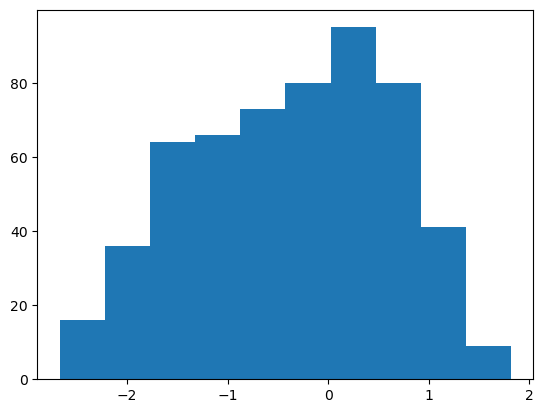

In [7]:
plt.figure() 
plt.hist(synth_drug.yhat.values)
plt.show() 

In [ ]:
model = model.eval()

In [9]:
x_res_batch = xs[synth_drug.sort_values('yhat', ascending=False).head(5).index.values].cuda()

drug_ixs = torch.tensor([i for i,n in enumerate(data.node_names_dict['input']) if 'DRUG__' in n], dtype=torch.long)

x_drug_prob = torch.zeros(1, drug_ixs.shape[0], device=x_res_batch.device, requires_grad=True)  

optim = torch.optim.Adam([x_drug_prob], lr=1e-2) 

losses = [] 
for i in range(1000): 
    optim.zero_grad() 
    x_drug = torch.nn.functional.gumbel_softmax(x_drug_prob, dim=-1, hard=True, tau=3)  
    xx = x_res_batch.clone() 
    xx[:, drug_ixs] = x_drug 
    yhat = model(xx) 
    loss = yhat.mean() 
    loss.backward() 
    optim.step() 
    print(i, loss.item(), end='\r') 
    losses.append(loss.item()) 

drug_comb_res = pd.DataFrame({'inhibitor':np.array(data.node_names_dict['input'])[drug_ixs], 'prob':x_drug_prob.softmax(dim=-1).detach().cpu().numpy().flatten()})



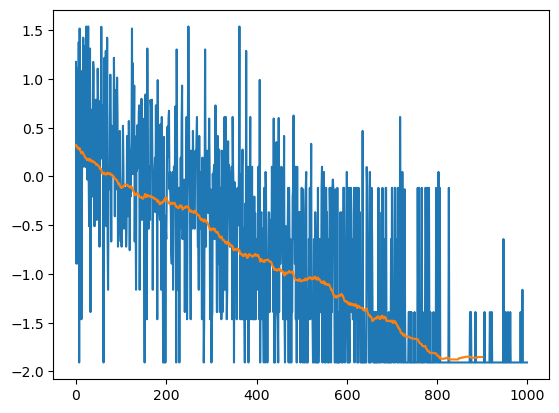

In [10]:
plt.figure() 
plt.plot(losses) 
# running mean 
plt.plot(np.convolve(losses, np.ones(100)/100, mode='valid')) 
plt.show() 

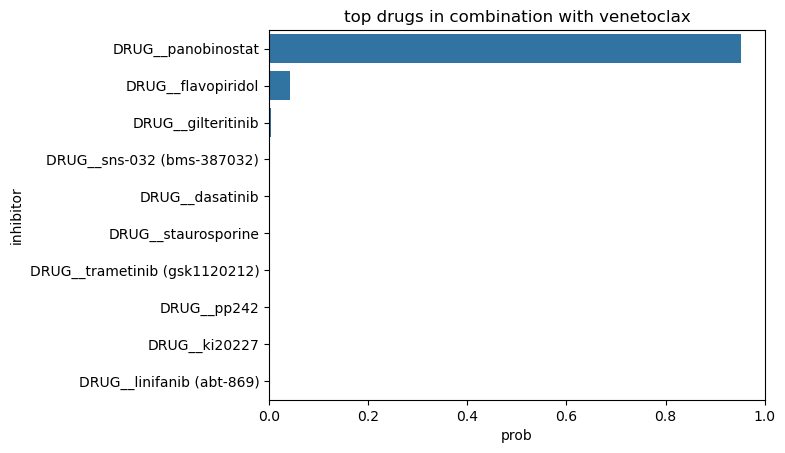

In [11]:
plt.figure() 
sbn.barplot(y='inhibitor', x='prob', orient='h', data=drug_comb_res.sort_values('prob', ascending=False).head(10)) 


plt.title('top drugs in combination with venetoclax')
plt.show() 